## ASTR-19 Group Project ##

Group Members: Iris DeGutis, Huyhanna Soliz, Gavin Rouillard

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [3]:
#function to read the tbl.text file of the data from NASA
def process():
    Day,RV,RVU = np.loadtxt('RCV.tbl.txt', skiprows=22, unpack=True)
    return(Day,RV,RVU)

In [4]:
#function which establishes the coefficients and values for the y_fit functions
def f_model(x, a,b,c,d):
    return a * np.sin(( 2 * np.pi * (x - b) ) / c) + d

In [5]:
#function which takes in our data, and guesstimate coefficients, and outputs the best fit coefficients
def find_curve(x,y,a,b,c,d):
    guess_params = [a, b, c, d]
    best_params, _ = optimize.curve_fit(f_model, x - x[0], y, p0=guess_params)
    best_a = best_params[0]
    best_b = best_params[1]
    best_c = best_params[2]
    best_d = best_params[3]
    return(best_a,best_b,best_c,best_d)

In [6]:
#Calling our function to import the text file data and output the tabular data as 3 1D arrays
Day, RV, RVU = process()

#first iteration of finding the bset fit curve
best_a,best_b,best_c,best_d = find_curve(Day,RV,125,-170,4500,25)

In [7]:
#Creating a 1D array to act as the x function which has a corresponding length to the y_fit function for graphing
x_fit = np.linspace(min(Day - Day[0]), max(Day - Day[0]), len(Day))

#defining the y_fit function based on the curve fitting optimization
y_fit = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

#subtracting the y_fit function from the data to find the residuals
y_res = RV - y_fit

In [8]:
#second iteration of finding the bset fit curve
best_a,best_b,best_c,best_d = find_curve(Day,y_res,125,-170,2000,10)

#defining the y_fit_two function based on the curve fitting optimization
y_fit_two = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

#subtracting the y_fit_two function from the data to find the residuals
y_res_two = y_res - y_fit_two

In [9]:
#third iteration of finding the bset fit curve
best_a,best_b,best_c,best_d = find_curve(Day,y_res_two,500,170,4000,-10)

#defining the y_fit_three function based on the curve fitting optimization
y_fit_three = best_a * np.sin(2 * np.pi * (x_fit - best_b) / best_c) + best_d

#subtracting the y_fit_three function from the data to find the residuals
y_res_three = y_res_two - y_fit_three

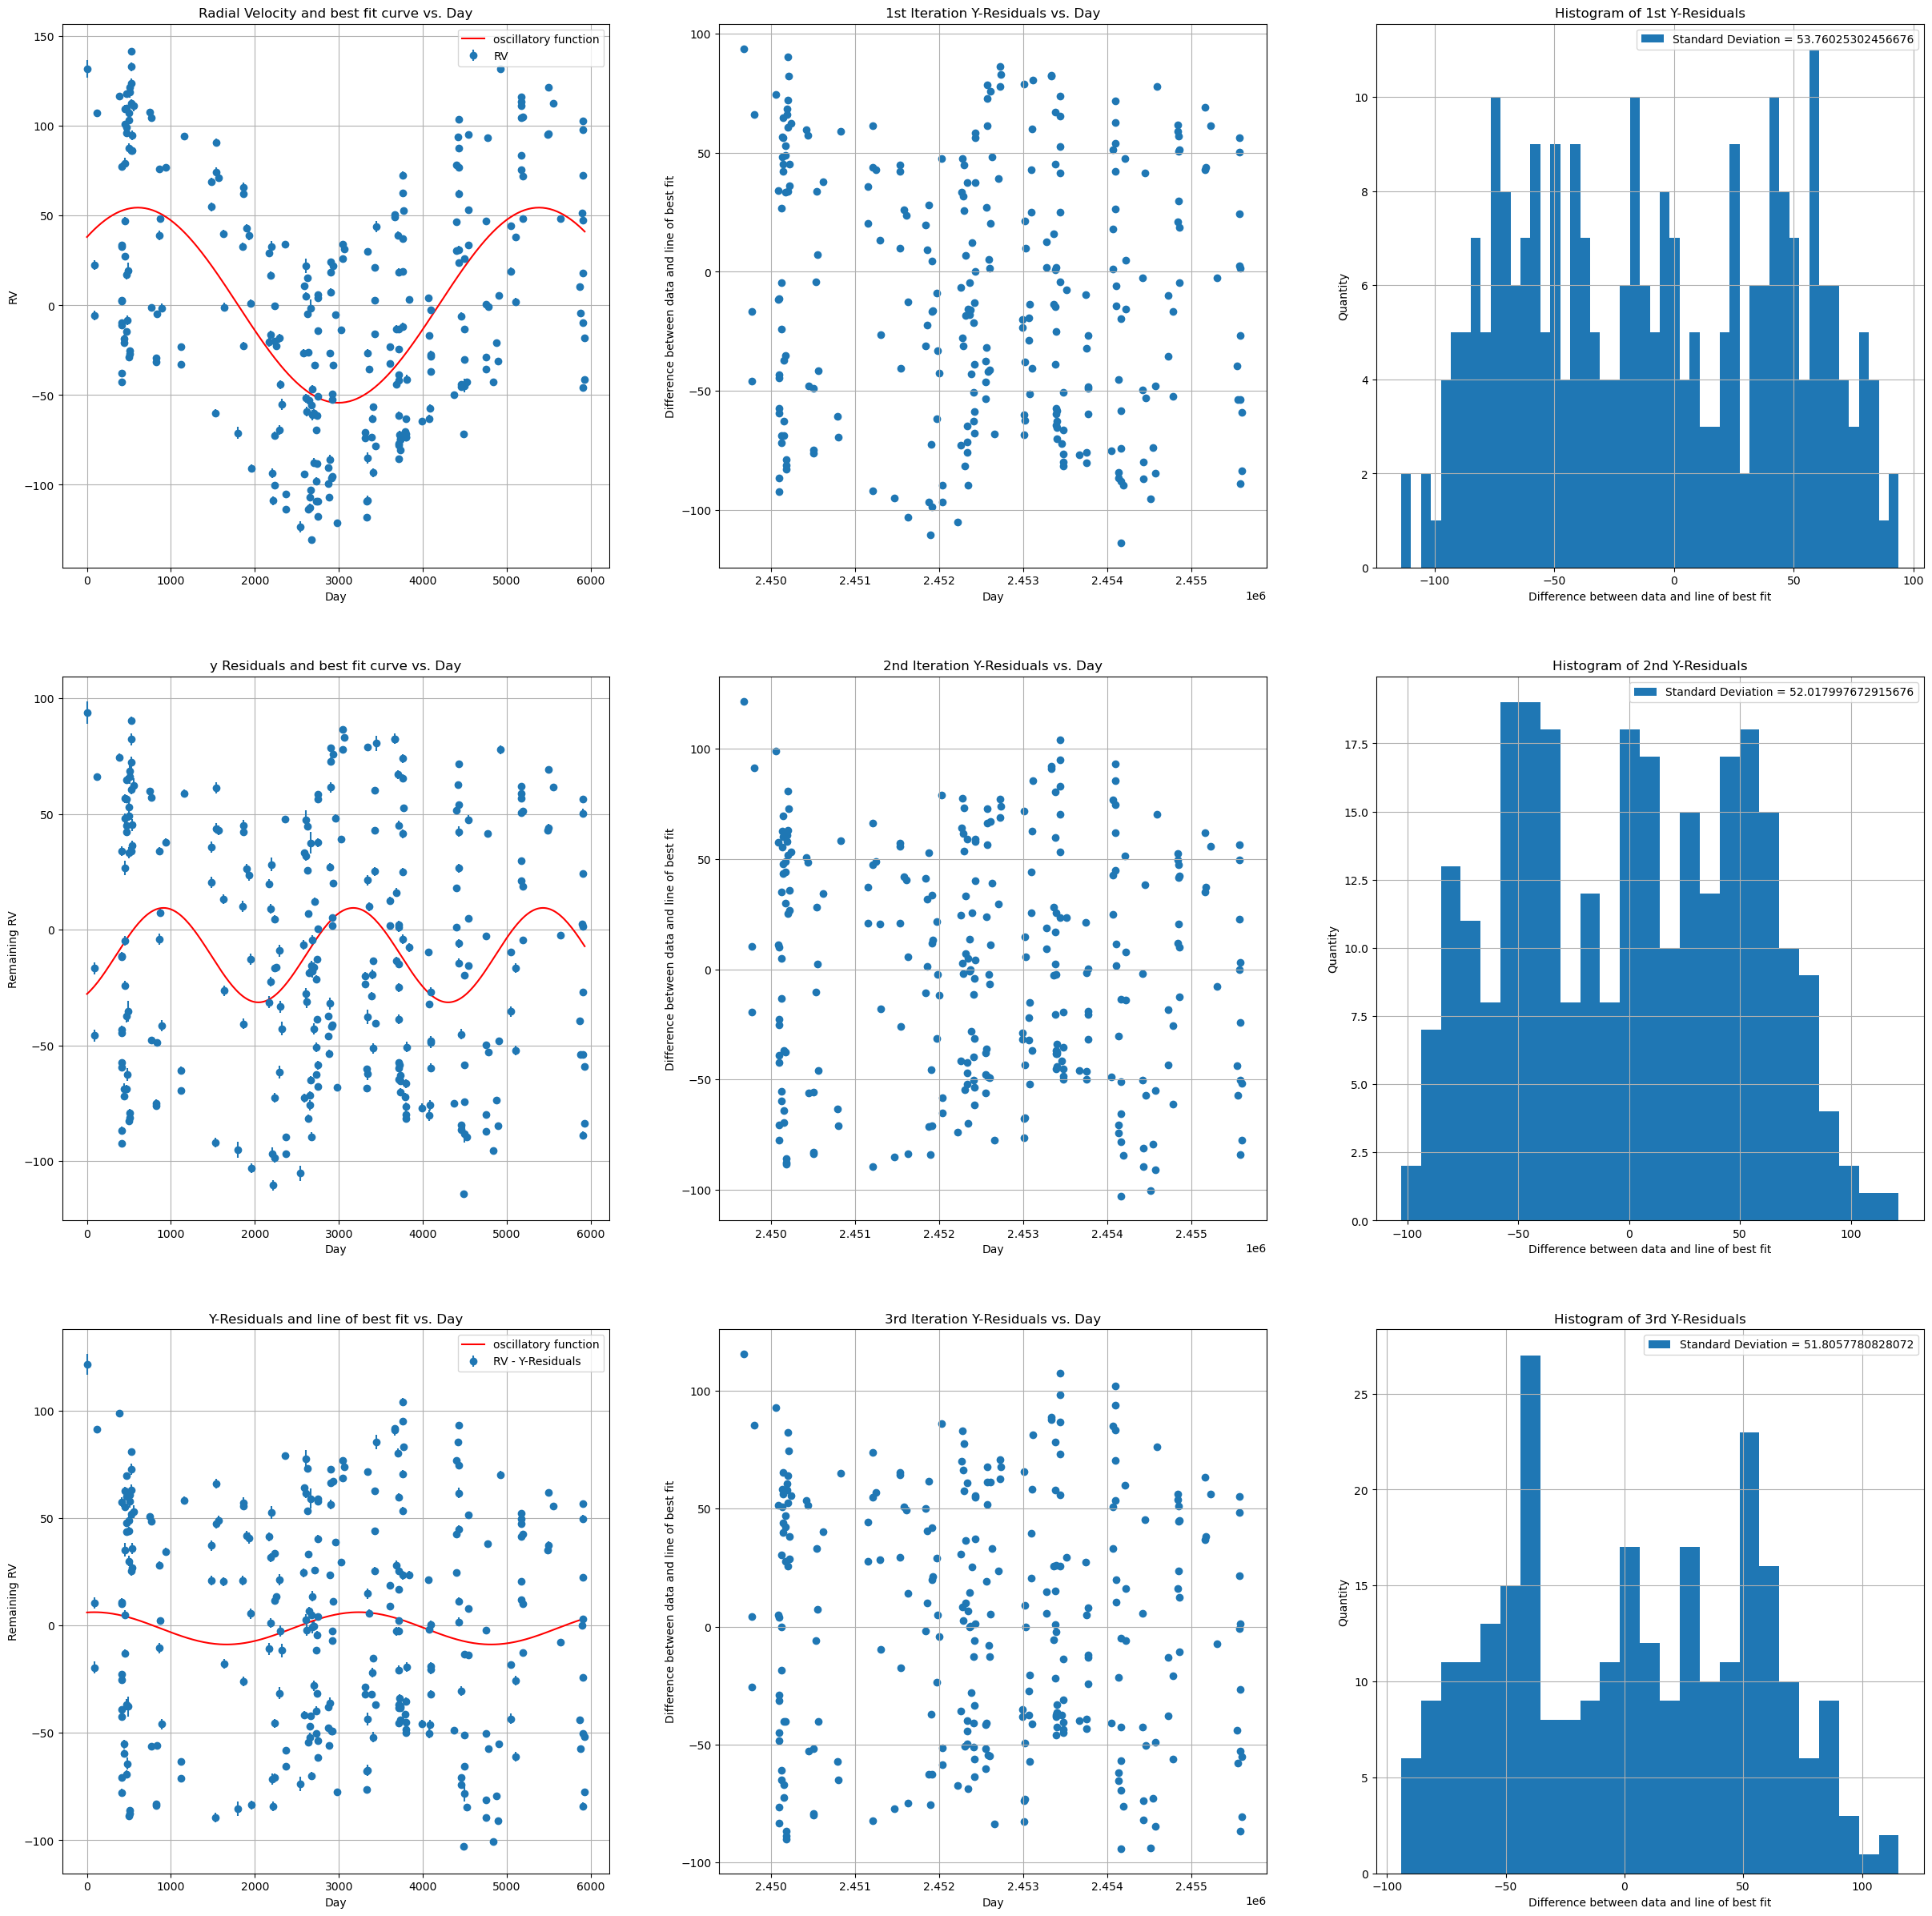

In [10]:
import matplotlib.pyplot as plt
import numpy as np
def chart():
    fig,ax = plt.subplots(3,3,figsize=(30,30))

    #RV data with 1st iteration best fit function plotted on top
    ax[0,0].set_title('Radial Velocity and best fit curve vs. Day')
    ax[0,0].errorbar(Day - Day[0], RV, yerr=RVU, fmt='o', label='RV')
    ax[0,0].plot(x_fit, y_fit, 'r-', label='oscillatory function')
    ax[0,0].set_xlabel('Day')
    ax[0,0].set_ylabel('RV')
    ax[0,0].legend()
    ax[0,0].grid(True)

    #scatter plot of 1st y-residuals
    ax[0,1].set_title('1st Iteration Y-Residuals vs. Day')
    ax[0,1].scatter(Day,y_res)
    ax[0,1].set_xlabel('Day')
    ax[0,1].set_ylabel('Difference between data and line of best fit')
    ax[0,1].grid(True)

    #histogram of 1st y-residuals
    ax[0,2].hist(y_res,bins=50,label=('Standard Deviation = '+str(np.std(y_res))))
    ax[0,2].set_title('Histogram of 1st Y-Residuals')
    ax[0,2].set_xlabel('Difference between data and line of best fit')
    ax[0,2].set_ylabel('Quantity')
    ax[0,2].legend()
    ax[0,2].grid(True)

    #y-residuals data with 2nd iteration best fit function plotted on top
    ax[1,0].set_title('y Residuals and best fit curve vs. Day')
    ax[1,0].errorbar(Day - Day[0], y_res, yerr=RVU, fmt='o', label='RV - Y-Residuals')
    ax[1,0].plot(x_fit, y_fit_two, 'r-', label='oscillatory function')
    ax[1,0].set_xlabel('Day')
    ax[1,0].set_ylabel('Remaining RV')
    ax[1,0].grid(True)

    #scatter plot of 2nd y-residuals
    ax[1,1].set_title('2nd Iteration Y-Residuals vs. Day')
    ax[1,1].set_xlabel('Day')
    ax[1,1].set_ylabel('Difference between data and line of best fit')
    ax[1,1].scatter(Day,y_res_two)
    ax[1,1].grid(True)

    #histogram of 2nd y-residuals
    ax[1,2].hist(y_res_two,bins=25,label=('Standard Deviation = '+str(np.std(y_res_two))))
    ax[1,2].set_xlabel('Difference between data and line of best fit')
    ax[1,2].set_ylabel('Quantity')
    ax[1,2].set_title('Histogram of 2nd Y-Residuals')
    ax[1,2].legend()
    ax[1,2].grid(True)

    #y-residuals data with 3rd iteration best fit function plotted on top
    ax[2,0].set_title('Y-Residuals and line of best fit vs. Day')
    ax[2,0].errorbar(Day - Day[0], y_res_two, yerr=RVU, fmt='o', label='RV - Y-Residuals')
    ax[2,0].plot(x_fit, y_fit_three, 'r-', label='oscillatory function')
    ax[2,0].set_xlabel('Day')
    ax[2,0].set_ylabel('Remaining RV')
    ax[2,0].legend()
    ax[2,0].grid(True)

    #scatter plot of 3rd y-residuals
    ax[2,1].set_title('3rd Iteration Y-Residuals vs. Day')
    ax[2,1].set_xlabel('Day')
    ax[2,1].set_ylabel('Difference between data and line of best fit')
    ax[2,1].scatter(Day,y_res_three)
    ax[2,1].grid(True)

    #histogram of 3rd y-residuals
    ax[2,2].hist(y_res_three,bins=25,label=('Standard Deviation = '+str(np.std(y_res_three))))
    ax[2,2].set_title('Histogram of 3rd Y-Residuals')
    ax[2,2].set_xlabel('Difference between data and line of best fit')
    ax[2,2].set_ylabel('Quantity')
    ax[2,2].grid(True)
    ax[2,2].legend()

    plt.show()

chart()

In [19]:
def mass(a,c,m):
    return(np.round(((abs(a)/28.4)*((c/365)**(1/3))*(m**(2/3))),3))
star_mass = 0.905
best_a,best_b,best_c,best_d = find_curve(Day,RV,125,-170,4500,25)
print("exoplanet 1 has a mass of ",str(mass(best_a,best_c,star_mass)),'times the mass of Jupiter')
best_a,best_b,best_c,best_d = find_curve(Day,y_res,125,-170,2000,10)
print("exoplanet 2 has a mass of ",str(mass(best_a,best_c,star_mass)),'times the mass of Jupiter')
best_a,best_b,best_c,best_d = find_curve(Day,y_res_two,500,170,4000,-10)
print("exoplanet 3 has a mass of ",str(mass(best_a,best_c,star_mass)),'times the mass of Jupiter')

exoplanet 1 has a mass of  4.223 times the mass of Jupiter
exoplanet 2 has a mass of  1.234 times the mass of Jupiter
exoplanet 3 has a mass of  0.508 times the mass of Jupiter


The star 55CnC has a mass of 0.905 times the sun, and the exoplanet has amplitude $K = 5.43926431*10^1 m/s$ (The amplitude of the occilatory function shown in the first figure) and a period $P = 4.77736070*10^3$ days, which gives $$M_{exoplanet} = (5.43926431*10^1 /{28.4 m/s})*(4.77736070*10^3 days)^{1/3}*(0.905)^{2/3} = 4.22298164*M_{Jupiter}$$ The exoplanet is about 4.21 times the mass of Jupiter. The closest exoplanet to this mass is 55 CnC d, which has a mass of about 3.86 times the mass of Jupiter.

The Standard Deviation of the Y-Residuals from subtracting the occilatory function is 53.76.

We included two more iterations of the process of finding the underlying occilatory function upon noticing that the Y-residual data appeared to still follow an occilation, which resulted in two more functions, hinting that these functions may be the result of the gravity of other exoplanets in the systems. Using the qu